<a href="https://colab.research.google.com/github/FARAHEltem/sleep-quality-classification/blob/main/Classification_de_la_qualit%C3%A9_du_sommeil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

In [ ]:
service['poor'] = fuzz.trimf(service.universe, [0, 0, 5])
service['average'] = fuzz.trimf(service.universe, [0, 5, 10])
service['good'] = fuzz.trimf(service.universe, [5, 10, 10])
quality['poor'] = fuzz.trimf(quality.universe, [0, 0, 5])
quality['average'] = fuzz.trimf(quality.universe, [0, 5, 10])
quality['good'] = fuzz.trimf(quality.universe, [5, 10, 10])
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])

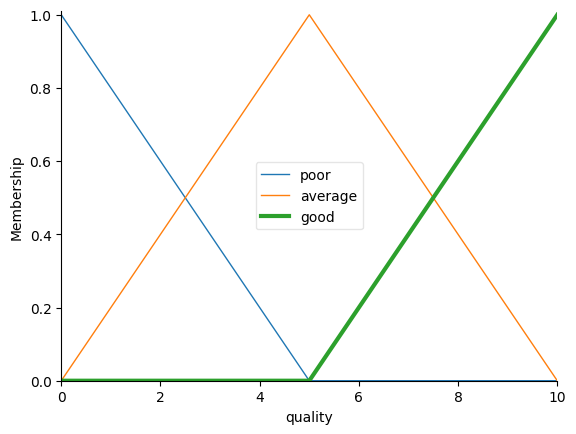

In [ ]:
quality['good'].view()

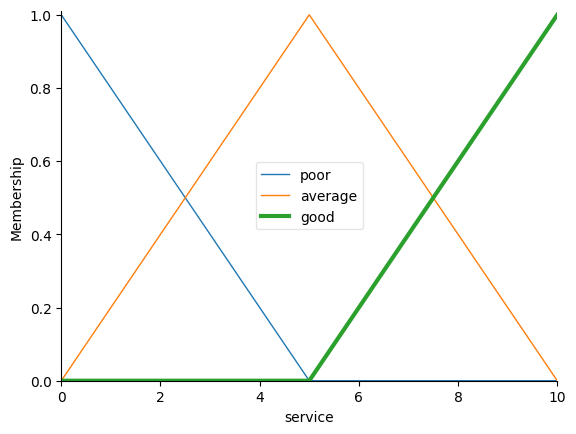

In [ ]:
service['good'].view()

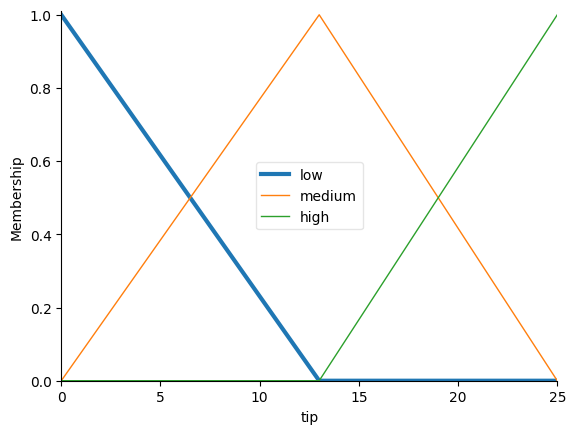

In [ ]:
tip['low'].view()

In [ ]:
rule1 = ctrl.Rule(quality['poor'] | service['poor'], tip['low'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['good'] | quality['good'], tip['high'])

In [ ]:
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

19.847607361963192


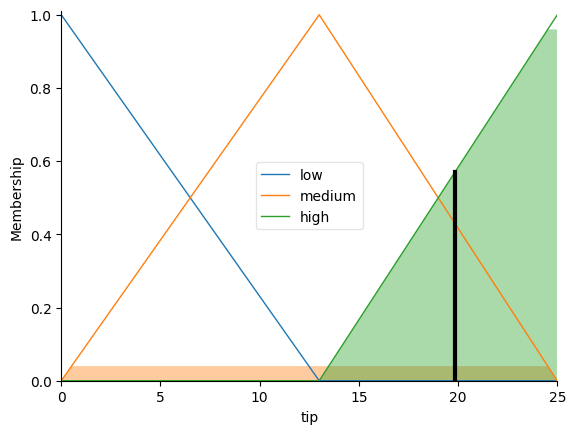

In [ ]:
tipping.input['quality'] = 6.5
tipping.input['service'] = 9.8
print(tipping.output['tip'])
tip.view(sim=tipping)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Please upload the 'Sleep_health_and_lifestyle_dataset.csv' file to your Colab environment.
# You can do this by clicking the folder icon on the left panel, then the upload icon.
# Once uploaded, the file will typically be in the '/content/' directory.
file_path = '/content/Sleep_health_and_lifestyle_dataset.csv' # Adjust path if your file is elsewhere

try:
    sleep_data = pd.read_csv(file_path, sep=",")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded and the path is correct.")
    # You can stop execution here if the file is critical
    # If you want to proceed without the file, you'll need to handle potential errors later.
    raise # Re-raise the error to stop execution if the file is missing

# 2. Check the number of rows
print(f"Number of rows in sleep_data: {len(sleep_data)}")

# 3. Create the histogram using seaborn and matplotlib
if 'Age' in sleep_data.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(sleep_data['Age'], bins=15, color="steelblue", edgecolor="black", alpha=0.7, kde=False)

    mean_age = sleep_data['Age'].mean()
    plt.axvline(mean_age, color="red", linestyle="dashed", linewidth=1, label=f'Moyenne = {mean_age:.1f} ans')

    plt.title("Distribution de l'âge des participants", fontsize=16)
    # Using suptitle for a subtitle effect as subplots_adjust is needed for proper spacing with regular subtitle
    plt.suptitle(f"Moyenne = {mean_age:.1f} ans", fontsize=12, y=0.95)
    plt.xlabel("Âge (années)", fontsize=14)
    plt.ylabel("Fréquence", fontsize=14)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'Age' column not found in the dataset. Please check your CSV file.")


Error: The file '/content/Sleep_health_and_lifestyle_dataset.csv' was not found. Please ensure it is uploaded and the path is correct.


FileNotFoundError: [Errno 2] No such file or directory: '/content/Sleep_health_and_lifestyle_dataset.csv'